In [1]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 43698, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 43698 (delta 33), reused 50 (delta 16), pack-reused 43627 (from 3)
Receiving objects: 100% (43698/43698), 487.63 MiB | 24.47 MiB/s, done.
Resolving deltas: 100% (111/111), done.
Updating files: 100% (119005/119005), done.


In [2]:
!pip install transformers[tf]

In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from transformers import AutoImageProcessor, SwinForImageClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = '/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_Vit_Data'
train_data_dir = os.path.join(BASE_DIR, 'train')
val_data_dir = os.path.join(BASE_DIR, 'val')

# --- 2. Initialize Swin ---
# Using the 'tiny' patch4 window7 model (efficient yet powerful)
model_name = "microsoft/swin-tiny-patch4-window7-224"
feature_extractor_swin = AutoImageProcessor.from_pretrained(model_name)
model_swin = SwinForImageClassification.from_pretrained(
    model_name,
    num_labels=4,
    ignore_mismatched_sizes=True
)
model_swin.to(device)

# --- 3. Dataset & Dataloaders ---
class PneumoniaDataset(Dataset):
    def __init__(self, data_dir, feature_extractor):
        self.data_dir = data_dir
        self.feature_extractor = feature_extractor
        self.image_paths = []
        self.labels = []
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}
        for class_name in self.classes:
            path = os.path.join(data_dir, class_name)
            for img in os.listdir(path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(path, img))
                    self.labels.append(self.class_to_idx[class_name])

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        inputs = self.feature_extractor(images=image, return_tensors='pt')
        return inputs['pixel_values'].squeeze(0), torch.tensor(self.labels[idx])

train_dataloader = DataLoader(PneumoniaDataset(train_data_dir, feature_extractor_swin), batch_size=32, shuffle=True)
val_dataloader = DataLoader(PneumoniaDataset(val_data_dir, feature_extractor_swin), batch_size=32, shuffle=False)

# --- 4. Optimizer ---
optimizer = AdamW(model_swin.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [4]:
epochs = 25
print(f"Starting Swin Transformer Training on {device}...")

for epoch in range(epochs):
    model_swin.train()
    train_loss, correct, total = 0, 0, 0
    for batch in train_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_swin(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Validation
    model_swin.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for v_batch in val_dataloader:
            v_inputs, v_labels = v_batch
            v_inputs, v_labels = v_inputs.to(device), v_labels.to(device)
            val_outputs = model_swin(v_inputs).logits
            _, v_pred = val_outputs.max(1)
            val_total += v_labels.size(0)
            val_correct += v_pred.eq(v_labels).sum().item()

    print(f"Swin Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_dataloader):.4f} | "
          f"Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%")

Starting Swin Transformer Training on cuda...
Swin Epoch 1/25 | Loss: 0.4556 | Train Acc: 81.02% | Val Acc: 85.58%
Swin Epoch 2/25 | Loss: 0.3102 | Train Acc: 86.97% | Val Acc: 87.48%
Swin Epoch 3/25 | Loss: 0.2376 | Train Acc: 90.00% | Val Acc: 89.01%
Swin Epoch 4/25 | Loss: 0.1708 | Train Acc: 93.17% | Val Acc: 89.38%
Swin Epoch 5/25 | Loss: 0.1087 | Train Acc: 95.81% | Val Acc: 88.59%
Swin Epoch 6/25 | Loss: 0.0705 | Train Acc: 97.47% | Val Acc: 90.63%
Swin Epoch 7/25 | Loss: 0.0463 | Train Acc: 98.45% | Val Acc: 91.19%
Swin Epoch 8/25 | Loss: 0.0392 | Train Acc: 98.54% | Val Acc: 88.64%
Swin Epoch 9/25 | Loss: 0.0347 | Train Acc: 98.73% | Val Acc: 89.89%
Swin Epoch 10/25 | Loss: 0.0274 | Train Acc: 99.01% | Val Acc: 91.74%
Swin Epoch 11/25 | Loss: 0.0310 | Train Acc: 98.90% | Val Acc: 90.82%
Swin Epoch 12/25 | Loss: 0.0207 | Train Acc: 99.31% | Val Acc: 91.42%
Swin Epoch 13/25 | Loss: 0.0219 | Train Acc: 99.26% | Val Acc: 91.47%
Swin Epoch 14/25 | Loss: 0.0232 | Train Acc: 99.15% |

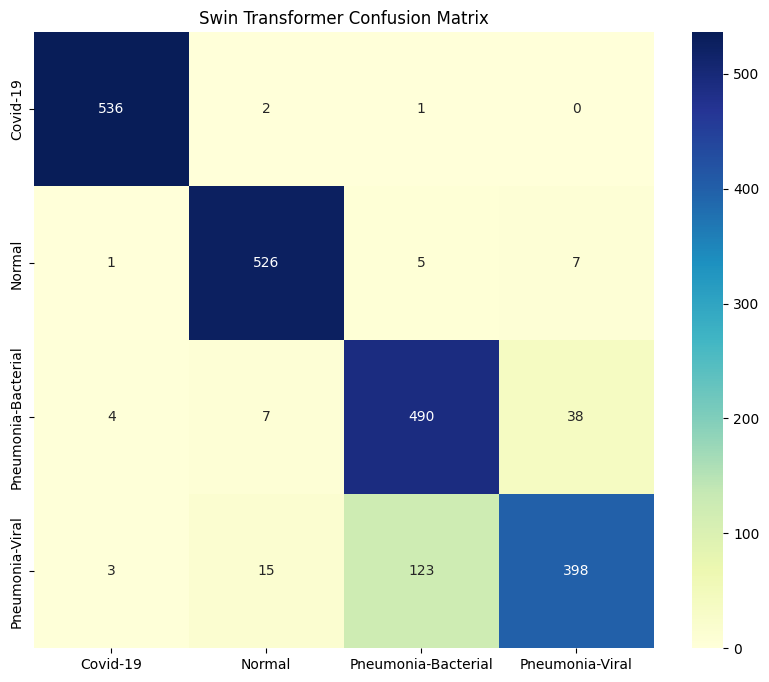


Swin Classification Report:

                     precision    recall  f1-score   support

           Covid-19       0.99      0.99      0.99       539
             Normal       0.96      0.98      0.97       539
Pneumonia-Bacterial       0.79      0.91      0.85       539
    Pneumonia-Viral       0.90      0.74      0.81       539

           accuracy                           0.90      2156
          macro avg       0.91      0.90      0.90      2156
       weighted avg       0.91      0.90      0.90      2156



In [5]:
model_swin.eval()
all_preds, all_labels = [], []
class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_swin(inputs).logits
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)
plt.title('Swin Transformer Confusion Matrix')
plt.show()

# Classification Report
print("\nSwin Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [1]:
import json

file = "swim_Tiny_Trained.ipynb"

with open(file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 🔥 Remove notebook-level widgets
nb.get("metadata", {}).pop("widgets", None)

# 🔥 Remove colab referenced widgets (just in case)
for cell in nb.get("cells", []):
    if "metadata" in cell and "colab" in cell["metadata"]:
        cell["metadata"]["colab"].pop("referenced_widgets", None)

with open(file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("✅ Fully cleaned notebook (widgets removed)")

✅ Fully cleaned notebook (widgets removed)
